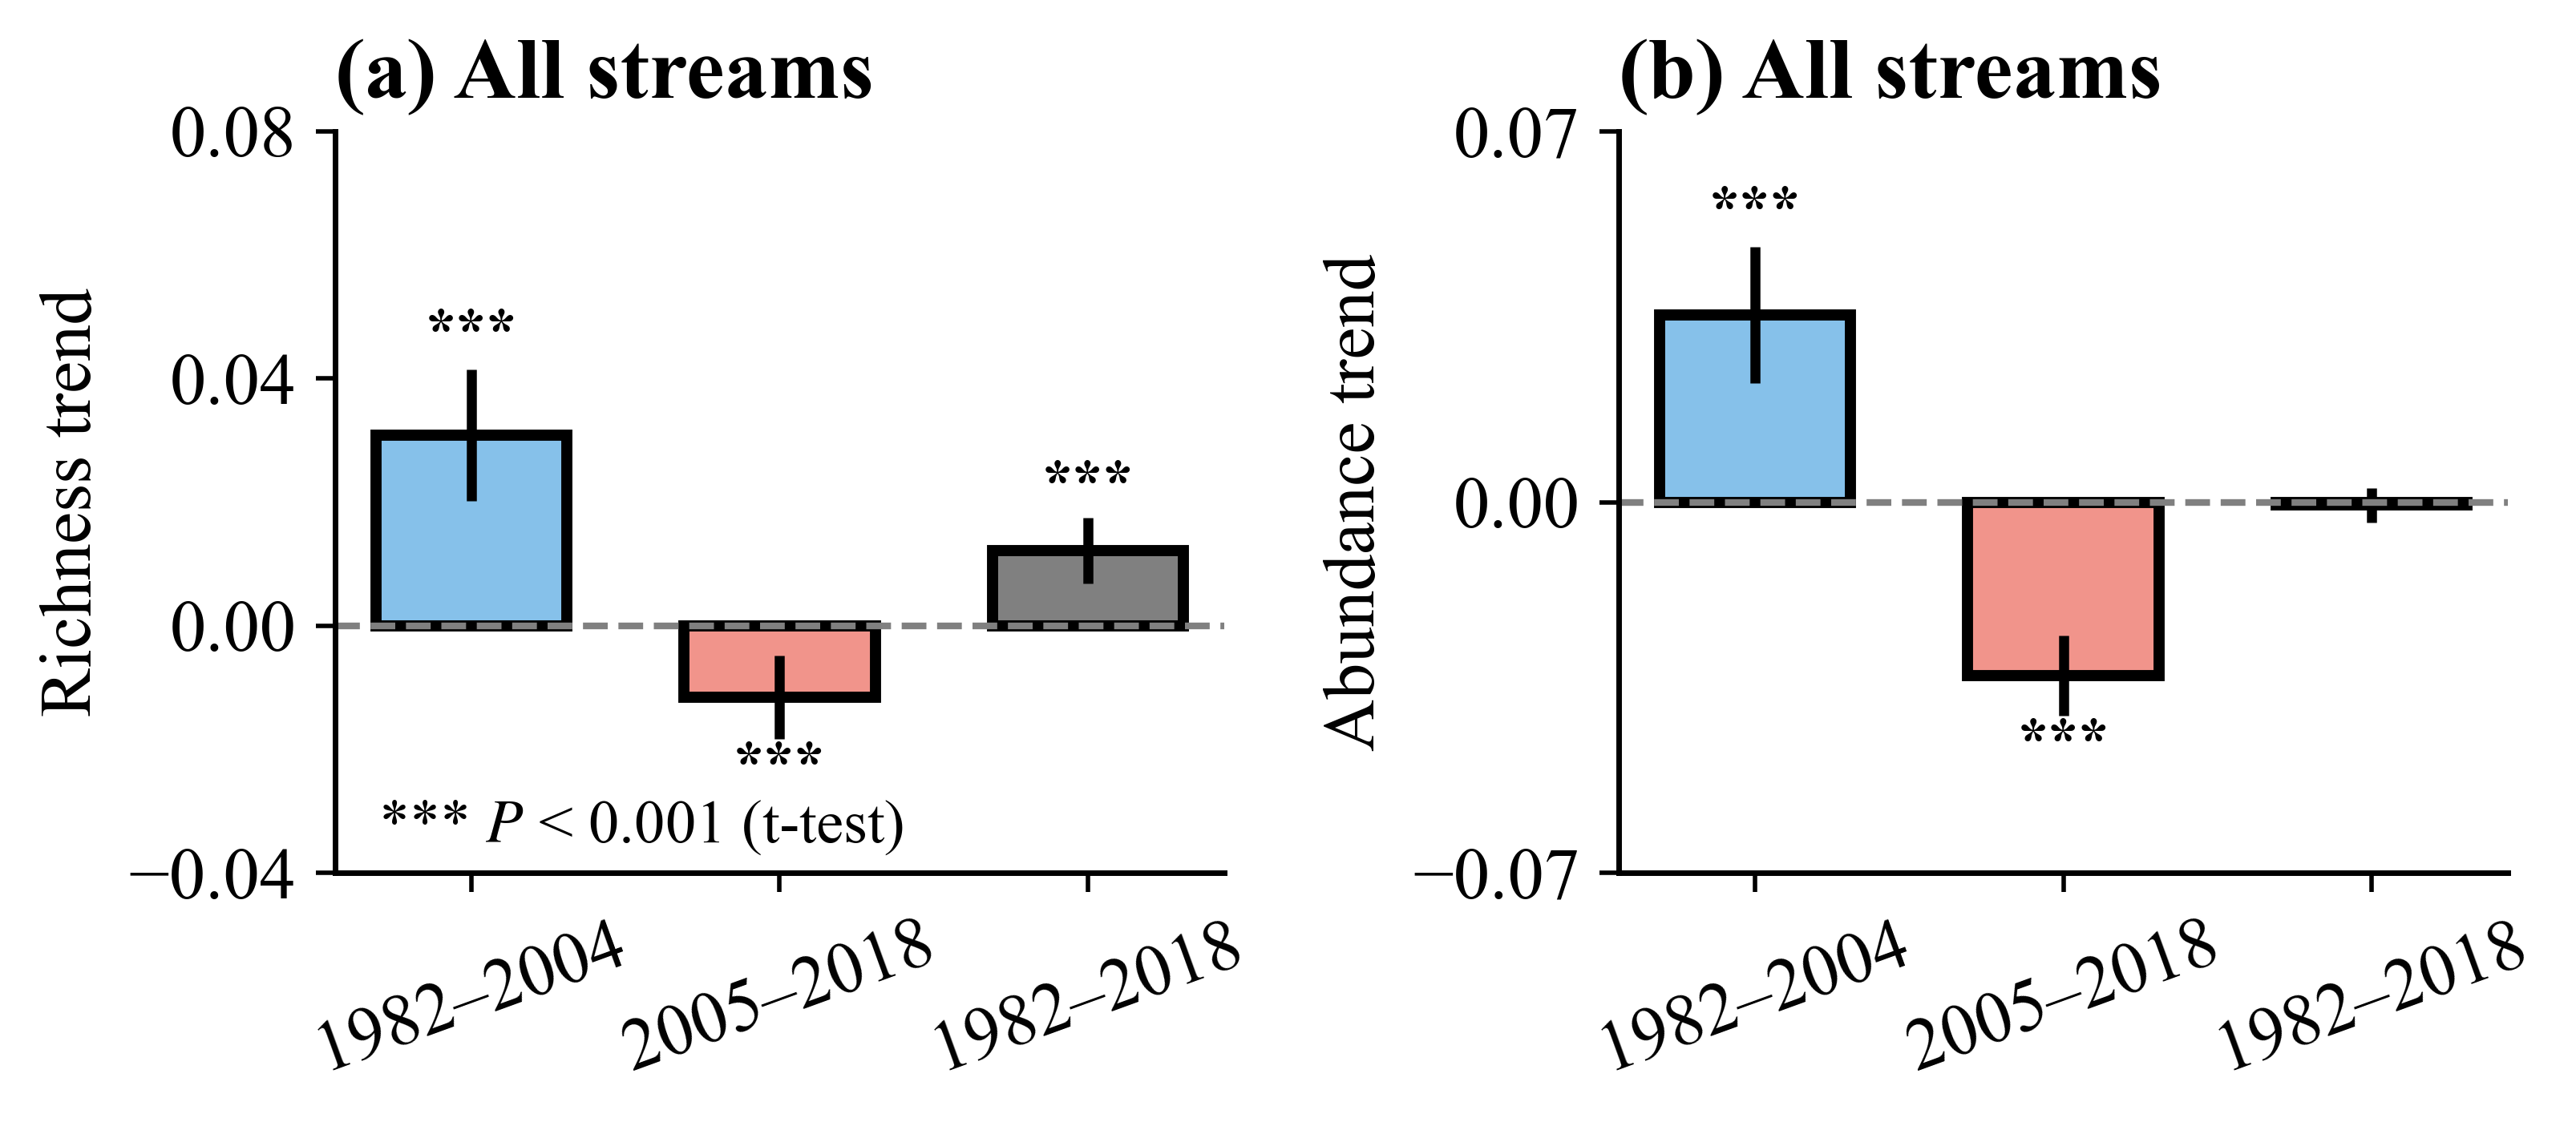

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 13,
    "mathtext.fontset": "stix",
    "axes.linewidth": 1,
    "axes.edgecolor": "black",
    "axes.grid": False,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.color": "black",
    "ytick.color": "black",
})

def get_star(vals):
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    if len(vals) < 2:
        return ""
    _, p = ttest_1samp(vals, 0)
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def mean_se(vals):
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    mean = np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else np.nan
    return mean, se

# =========================================================
# data
# =========================================================
df_rich_seg = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Richness_segmented_2004.csv")
df_rich_all = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Richness_slope.csv")

df_ab_seg = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Abundance_segmented_2004.csv")
df_ab_all = pd.read_csv(r"D:\NC\Data\rivernet\inputdata\Abundance_slope.csv")

period_labels = ["1982–2004", "2005–2018", "1982–2018"]
bar_colors = ["#86c1ea", "#f1948b", "gray"]

# =========================================================
# figure
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.0), dpi=500)

# =========================================================
# (a) All richness bar
# =========================================================
ax = axes[0]

vals_1 = df_rich_seg[df_rich_seg["period"] == "1982_2004"]["sen_richness"].dropna()
vals_2 = df_rich_seg[df_rich_seg["period"] == "2005_2018"]["sen_richness"].dropna()
vals_3 = df_rich_all["slope_richness"].dropna()

vals_list = [vals_1, vals_2, vals_3]
means = []
ses = []
stars = []

for vals in vals_list:
    m, se = mean_se(vals)
    means.append(m)
    ses.append(se)
    stars.append(get_star(vals))

x = np.arange(3)

ax.bar(
    x, means,
    width=0.62,
    edgecolor="black",
    color=bar_colors,
    linewidth=2
)

ax.errorbar(
    x, means,
    yerr=np.array(ses) * 1.96,
    fmt="none",
    ecolor="black",
    lw=1.8,
    capsize=0
)

for i, star in enumerate(stars):
    if star:
        ci = ses[i] * 1.96 if np.isfinite(ses[i]) else 0
        y = means[i] + ci * 1.1 if means[i] >= 0 else means[i] - ci * 1.1
        ax.text(
            x[i], y, star,
            ha="center",
            va="bottom" if means[i] >= 0 else "top",
            fontsize=11,
            fontweight="bold"
        )

ax.axhline(0, color="gray", lw=1.2, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(period_labels, rotation=20)
ax.set_ylabel("Richness trend")
ax.set_ylim(-0.04, 0.08)
ax.set_yticks([-0.04, 0.00, 0.04, 0.08])
ax.set_title("(a)", loc="left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.text(
    -0.3, -0.035,
    r"*** $P$ < 0.001 (t-test)",
    fontsize=11
)

# =========================================================
# (b) All abundance bar
# =========================================================
ax = axes[1]

vals_1 = df_ab_seg[df_ab_seg["period"] == "1982_2004"]["sen_abundance_std"].dropna()
vals_2 = df_ab_seg[df_ab_seg["period"] == "2005_2018"]["sen_abundance_std"].dropna()
vals_3 = df_ab_all["slope_abundance"].dropna()

vals_list = [vals_1, vals_2, vals_3]
means = []
ses = []
stars = []

for vals in vals_list:
    m, se = mean_se(vals)
    means.append(m)
    ses.append(se)
    stars.append(get_star(vals))

x = np.arange(3)

ax.bar(
    x, means,
    width=0.62,
    edgecolor="black",
    color=bar_colors,
    linewidth=2
)

ax.errorbar(
    x, means,
    yerr=np.array(ses) * 1.96,
    fmt="none",
    ecolor="black",
    lw=1.8,
    capsize=0
)

for i, star in enumerate(stars):
    if star:
        ci = ses[i] * 1.96 if np.isfinite(ses[i]) else 0
        y = means[i] + ci * 1.1 if means[i] >= 0 else means[i] - ci * 1.1
        ax.text(
            x[i], y, star,
            ha="center",
            va="bottom" if means[i] >= 0 else "top",
            fontsize=11,
            fontweight="bold"
        )

ax.axhline(0, color="gray", lw=1.2, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(period_labels, rotation=20)
ax.set_ylabel("Abundance trend")
ax.set_ylim(-0.07, 0.07)
ax.set_yticks([-0.07, 0.00, 0.07])
ax.set_title("(b)", loc="left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\extendFig4.png", dpi=500, bbox_inches="tight")
plt.show()